# Statistical Arbitrage in Cryptocurrency Markets
## A Quantitative Finance Research Project

**Course:** Quantitative Finance &nbsp;|&nbsp; **Date:** May 2026

---

### Research Questions

> *Do momentum and mean-reversion effects exist in crypto, and can they be combined into a profitable, cost-aware trading strategy?*

| # | Hypothesis | Mechanism |
|---|-----------|-----------|
| H1 | **Momentum** (7–90 day) earns positive risk-adjusted returns | Slow information diffusion; trend-following retail flows |
| H2 | **Short-term reversal** (1–3 day) earns positive returns | Overreaction by retail; liquidity shocks that quickly revert |
| H3 | **Volume-weighted signals** beat equal-weighted ones | High-volume moves carry more information |
| H4 | A **combined portfolio** (momentum + reversal) raises Sharpe | Weak correlation between signal families = diversification |

### Strategy design
- **Universe**: Top 25 cryptocurrencies by market cap (Binance, no API key needed)
- **Data**: 3+ years daily / 18 months hourly OHLCV
- **Strategy**: Long top quintile, short bottom quintile of cross-sectional signal ranks
- **Costs**: 20 bps per one-way trade (market orders)  |  7 bps (limit orders)
- **Benchmark**: BTC/USDT buy-and-hold

---
> **How to run:** `Runtime > Run all`.
> Data is fetched from Binance on first run (~3-5 min) and cached in `/content/data/`.
> Subsequent runs in the same session are instant.


In [1]:
# ── Install packages not pre-installed on Colab ───────────────────────────────
import subprocess, sys
pkgs = ["ccxt", "pyarrow", "statsmodels"]
for p in pkgs:
    try:
        __import__(p)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", p, "-q"])

# ── Imports ───────────────────────────────────────────────────────────────────
from __future__ import annotations
import warnings, time, logging
from datetime import datetime
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import ccxt
import statsmodels.api as sm

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.ERROR)

# Style
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 20)

print(f"Python {sys.version.split()[0]}  |  NumPy {np.__version__}  |  Pandas {pd.__version__}")
print("All imports OK")

# ── Configuration ─────────────────────────────────────────────────────────────
TOP_CRYPTOS = [
    "BTC/USDT", "ETH/USDT", "BNB/USDT", "SOL/USDT", "XRP/USDT",
    "DOGE/USDT", "ADA/USDT", "AVAX/USDT", "LINK/USDT", "DOT/USDT",
    "MATIC/USDT", "LTC/USDT", "BCH/USDT", "UNI/USDT", "ATOM/USDT",
    "XLM/USDT", "ETC/USDT", "ALGO/USDT", "FIL/USDT", "TRX/USDT",
    "NEAR/USDT", "APT/USDT", "OP/USDT", "ARB/USDT", "VET/USDT",
]

DAILY_START          = datetime(2021, 1, 1)
HOURLY_START         = datetime(2023, 11, 1)
MARKET_COST_BPS      = 20        # 0.20% taker fee
LIMIT_COST_BPS       = 7         # 0.07% maker fee
MOMENTUM_WINDOWS     = [1, 3, 7, 14, 30, 60, 90]
REVERSAL_WINDOWS     = [1, 3]
LONG_THRESHOLD       = 0.80      # top quintile
SHORT_THRESHOLD      = 0.20      # bottom quintile
MIN_ASSETS           = 8         # skip rebalance if fewer coins have valid signal
PERIODS_PER_YEAR     = 365       # crypto = 24/7/365

# Train / Validation split
TRAIN_START = "2021-01-01"
TRAIN_END   = "2022-12-31"
VAL_START   = "2023-01-01"
VAL_END     = "2025-12-31"

RAW_DAILY  = Path("data/raw/daily")
RAW_HOURLY = Path("data/raw/hourly")
for d in [RAW_DAILY, RAW_HOURLY]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Universe: {len(TOP_CRYPTOS)} coins  |  Daily start: {DAILY_START.date()}")
print(f"Train: {TRAIN_START} to {TRAIN_END}  |  Val: {VAL_START} to {VAL_END}")
print("Configuration ready")


C:\Users\yomis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.0.post1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


Python 3.12.10  |  NumPy 2.2.6  |  Pandas 2.2.2
All imports OK
Universe: 25 coins  |  Daily start: 2021-01-01
Train: 2021-01-01 to 2022-12-31  |  Val: 2023-01-01 to 2025-12-31
Configuration ready


In [2]:
# ── Data pipeline: fetch OHLCV from Binance, cache as Parquet ─────────────────
# No API key required — all endpoints are public.
# On first run: ~3-5 min for daily, ~5-8 min for hourly (25 coins).
# On subsequent runs in the same session: instant (reads from cache).

_TF_MS = {"1d": 86_400_000, "1h": 3_600_000}

def _get_exchange():
    "Try binance.com first; auto-fall back to binanceus if geo-blocked."
    for eid, kw in [("binance",   {"enableRateLimit": True, "options": {"defaultType": "spot"}}),
                    ("binanceus", {"enableRateLimit": True})]:
        try:
            exc = getattr(ccxt, eid)(kw)
            exc.fetch_ticker("BTC/USDT")
            print(f"Connected to {eid}")
            return exc
        except ccxt.NetworkError:
            pass
    raise RuntimeError("Cannot reach Binance or Binance US. Check internet connection.")

def _sym2file(sym):
    return sym.replace("/", "_")

def _file2sym(stem):
    return stem.replace("_", "/", 1)

def _fetch_ohlcv_paginated(exchange, symbol, timeframe, since_ms, until_ms):
    tf_ms = _TF_MS[timeframe]
    bars, cur = [], since_ms
    retries = 0
    while cur < until_ms:
        try:
            batch = exchange.fetch_ohlcv(symbol, timeframe, since=cur, limit=1000)
            retries = 0
        except ccxt.NetworkError:
            retries += 1
            if retries >= 3:
                break
            time.sleep(5 * retries)
            continue
        except ccxt.ExchangeError:
            break
        if not batch:
            break
        bars.extend(batch)
        cur = batch[-1][0] + tf_ms
        if len(batch) < 1000:
            break
        time.sleep(0.3)
    if not bars:
        return pd.DataFrame(columns=["open","high","low","close","volume"])
    df = pd.DataFrame(bars, columns=["ts","open","high","low","close","volume"])
    df["ts"] = pd.to_datetime(df["ts"], unit="ms")
    df = df.set_index("ts").sort_index()
    df = df[~df.index.duplicated(keep="first")]
    df = df[df.index < pd.Timestamp(until_ms, unit="ms")]
    for c in ["open","high","low","close","volume"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def _fetch_and_store_one(exchange, symbol, timeframe, since_dt, save_dir, force):
    save_dir.mkdir(parents=True, exist_ok=True)
    fpath = save_dir / f"{_sym2file(symbol)}.parquet"
    existing = None
    since_ms = int(since_dt.timestamp() * 1000)
    if fpath.exists() and not force:
        try:
            existing = pd.read_parquet(fpath)
            if not existing.empty:
                since_ms = int(existing.index.max().timestamp()*1000) + _TF_MS[timeframe]
        except Exception:
            existing = None
    until_ms = int(datetime.utcnow().timestamp() * 1000)
    if since_ms >= until_ms:
        return True
    new = _fetch_ohlcv_paginated(exchange, symbol, timeframe, since_ms, until_ms)
    if new.empty and existing is None:
        return False
    combined = pd.concat([existing, new]) if (existing is not None and not new.empty) else (existing if existing is not None else new)
    combined = combined[~combined.index.duplicated(keep="last")].sort_index()
    combined.to_parquet(fpath, compression="snappy")
    return True

def fetch_and_store_universe(timeframe="1d", symbols=None, force=False):
    "Fetch OHLCV for all coins and cache as Parquet. Safe to re-run (incremental)."
    if symbols is None:
        symbols = TOP_CRYPTOS
    since_dt = DAILY_START if timeframe == "1d" else HOURLY_START
    save_dir = RAW_DAILY if timeframe == "1d" else RAW_HOURLY
    try:
        exc = _get_exchange()
    except RuntimeError as e:
        print(f"[FETCH ERROR] {e}")
        return {s: False for s in symbols}
    try:
        markets = exc.load_markets()
        valid = [s for s in symbols if s in markets]
    except Exception:
        valid = symbols
    results = {}
    for sym in tqdm(valid, desc=f"Fetching {timeframe}"):
        results[sym] = _fetch_and_store_one(exc, sym, timeframe, since_dt, save_dir, force)
        time.sleep(0.2)
    ok = sum(results.values())
    print(f"  {timeframe}: {ok}/{len(valid)} symbols OK")
    return results

def load_ohlcv_wide(timeframe="1d", field="close", symbols=None):
    """Load one OHLCV field as a wide DataFrame (dates x symbols)."""
    save_dir = RAW_DAILY if timeframe == "1d" else RAW_HOURLY
    files = sorted(save_dir.glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No data in {save_dir}. Run fetch_and_store_universe('{timeframe}') first.")
    out = {}
    for fp in files:
        sym = _file2sym(fp.stem)
        if symbols is not None and sym not in symbols:
            continue
        try:
            df = pd.read_parquet(fp)
            if field in df.columns:
                out[sym] = df[field]
        except Exception:
            pass
    wide = pd.DataFrame(out)
    wide.index = pd.to_datetime(wide.index)
    if wide.index.tz is not None:
        wide.index = wide.index.tz_localize(None)
    return wide.sort_index()

def load_all_fields(timeframe="1d", symbols=None):
    """Return dict of {field: wide_df} for all five OHLCV fields."""
    return {f: load_ohlcv_wide(timeframe, f, symbols) for f in ["open","high","low","close","volume"]}

print("Data pipeline functions ready")


Data pipeline functions ready


In [3]:
# ── Signal library: momentum and reversal signals ─────────────────────────────
#
# Look-ahead-bias rule: signal[t] uses data through close of day t.
# The backtester applies a 1-period lag: w[t] earns return r[t+1].

import numpy as np
import pandas as pd

# ─── Utilities ────────────────────────────────────────────────────────────────
def _log_ret(prices):
    return np.log(prices / prices.shift(1))

def _cs_zscore(signal):
    """Demean and scale cross-sectionally at every date (market-neutral)."""
    mu  = signal.mean(axis=1)
    sig = signal.std(axis=1).replace(0, np.nan)
    return signal.sub(mu, axis=0).div(sig, axis=0)

def _cs_rank(signal):
    return signal.rank(axis=1, pct=True, na_option="keep")

def _winsorize(signal, clip=3.0):
    return signal.clip(-clip, clip)

# ─── Momentum ────────────────────────────────────────────────────────────────
def mom_simple(close, window):
    """Time-series momentum: log-return over 'window' days."""
    r = _log_ret(close)
    mp = min(max(window // 2, 1), window)
    return _cs_zscore(r.rolling(window, min_periods=mp).sum())

def mom_cross_section(close, window):
    """Cross-sectional rank of past-window return, scaled to [-1, 1]."""
    r = _log_ret(close)
    mp = min(max(window // 2, 1), window)
    cum = r.rolling(window, min_periods=mp).sum()
    return (_cs_rank(cum) - 0.5) * 2.0

def mom_volume_weighted(close, volume, window):
    """
    Volume-weighted momentum.
    High-volume days are up-weighted (conviction > noise).
    signal = sum(r_t * vol_t / avg_vol, window)
    """
    r = _log_ret(close)
    mp = min(max(window // 2, 1), window)
    avg_vol = volume.rolling(window, min_periods=mp).mean()
    rel_vol = volume / avg_vol.replace(0, np.nan)
    return _cs_zscore((r * rel_vol).rolling(window, min_periods=mp).sum())

def mom_weekday(close, min_weeks=8):
    """
    Weekday seasonality: expanding mean return per weekday per coin.
    Separates institutional (Mon-Fri) from retail (weekend) flows.
    """
    r = _log_ret(close)
    sig = pd.DataFrame(index=close.index, columns=close.columns, dtype=float)
    for dow in range(7):
        mask = r.index.dayofweek == dow
        day_r = r[mask]
        exp_mean = day_r.expanding(min_periods=min_weeks).mean()
        sig.loc[mask] = exp_mean.values
    return _cs_zscore(sig.fillna(0.0))

def all_momentum_signals(close, volume):
    """Build the full momentum signal library. Returns {name: signal_df}."""
    sigs = {}
    for w in MOMENTUM_WINDOWS:
        sigs[f"mom_{w}d"] = mom_simple(close, w)
    for w in [7, 30, 90]:
        sigs[f"cs_mom_{w}d"] = mom_cross_section(close, w)
    for w in [7, 14, 30]:
        sigs[f"vw_mom_{w}d"] = mom_volume_weighted(close, volume, w)
    sigs["weekday_mom"] = mom_weekday(close)
    return sigs

# ─── Reversal ────────────────────────────────────────────────────────────────
def rev_short(close, window):
    """
    Short-horizon reversal.
    Negative of recent w-day return: expect bounce after sharp drop.
    """
    r = _log_ret(close)
    mp = min(max(window // 2, 1), window)
    return _cs_zscore(_winsorize(-r.rolling(window, min_periods=mp).sum()))

def rev_low_volume(close, volume, window=3, vol_lookback=30, vol_pct=0.35):
    """
    Low-volume reversal.
    Noise moves (low volume) revert more reliably than information moves.
    """
    r = _log_ret(close)
    mp = min(max(window // 2, 1), window)
    recent = r.rolling(window, min_periods=mp).sum()
    thresh = volume.rolling(vol_lookback, min_periods=vol_lookback//2).quantile(vol_pct)
    is_low = (volume < thresh).astype(float)
    return _cs_zscore(_winsorize(-recent * is_low))

def rev_pairs_spread(close, zscore_win=60, corr_win=90, min_corr=0.65):
    """
    Pairs spread reversal (simplified statistical arbitrage).
    For each highly-correlated pair (i,j), compute the rolling z-score of
    ln(P_i) - ln(P_j). A high z-score means i is expensive vs j → short i, long j.
    """
    lp  = np.log(close.replace(0, np.nan))
    ret = lp.diff()
    syms = list(close.columns)
    n = len(syms)
    sig  = pd.DataFrame(0.0, index=close.index, columns=close.columns)
    cnt  = pd.DataFrame(0,   index=close.index, columns=close.columns)
    print("  (pairs spread: computing pairwise z-scores...)")
    for i in range(n):
        for j in range(i+1, n):
            si, sj = syms[i], syms[j]
            rc = (ret[[si,sj]]
                  .rolling(corr_win, min_periods=corr_win//2)
                  .corr().unstack()[si][sj])
            active = rc >= min_corr
            spread = lp[si] - lp[sj]
            mu = spread.rolling(zscore_win, min_periods=zscore_win//2).mean()
            sd = spread.rolling(zscore_win, min_periods=zscore_win//2).std()
            z  = ((spread - mu) / sd.replace(0, np.nan)).clip(-3, 3)
            za = z.where(active, other=0.0).fillna(0.0)
            sig[si] += -za
            sig[sj] +=  za
            pair_ok = (active & z.notna()).astype(int)
            cnt[si] += pair_ok
            cnt[sj] += pair_ok
    safe_cnt = cnt.replace(0, np.nan)
    sig = (sig / safe_cnt).fillna(0.0)
    return _cs_zscore(sig)

def rev_macro_regime(close, btc_col="BTC/USDT", window=3, vol_win=20, amplify=1.5):
    """
    Macro-regime reversal.
    BTC realized vol proxies crypto market stress.
    High BTC vol → herding amplifies moves → reversals are stronger.
    """
    col = btc_col if btc_col in close.columns else close.columns[0]
    btc_r   = np.log(close[col] / close[col].shift(1))
    btc_vol = btc_r.rolling(vol_win, min_periods=vol_win//2).std() * np.sqrt(365)
    vol_pct = btc_vol.rolling(252, min_periods=60).rank(pct=True).fillna(0.5)
    base    = rev_short(close, window)
    scalar  = 1.0 + (amplify - 1.0) * vol_pct
    return base.mul(scalar.reindex(base.index).fillna(1.0), axis=0)

def all_reversal_signals(close, volume, btc_col="BTC/USDT"):
    """Build the full reversal signal library. Returns {name: signal_df}."""
    sigs = {}
    for w in REVERSAL_WINDOWS:
        sigs[f"rev_{w}d"] = rev_short(close, w)
    sigs["low_vol_rev"] = rev_low_volume(close, volume)
    sigs["pairs_rev"]   = rev_pairs_spread(close)
    sigs["macro_rev"]   = rev_macro_regime(close, btc_col=btc_col)
    return sigs

print("Signal functions ready")


Signal functions ready


In [4]:
# ── Backtester ────────────────────────────────────────────────────────────────
#
# Architecture (no look-ahead bias):
#   signal[t] → weights[t] → earns r[t+1]
#   net_ret[t+1] = sum(w[t] * r[t+1]) - turnover[t] * cost_bps/10000
#
# Dollar-neutral: long leg sums to +1, short leg sums to -1.

def signal_to_weights(signal):
    ranks = signal.rank(axis=1, pct=True, na_option="keep")
    w = pd.DataFrame(0.0, index=signal.index, columns=signal.columns)
    w[ranks >= LONG_THRESHOLD]  =  1.0
    w[ranks <= SHORT_THRESHOLD] = -1.0
    n_valid = signal.notna().sum(axis=1)
    too_few = n_valid < MIN_ASSETS
    long_s  = w.clip(lower=0).sum(axis=1).replace(0, np.nan)
    short_s = w.clip(upper=0).sum(axis=1).abs().replace(0, np.nan)
    w = w.clip(lower=0).div(long_s, axis=0).fillna(0.0) +         w.clip(upper=0).div(short_s, axis=0).fillna(0.0)
    w[too_few] = 0.0
    return w

def compute_turnover(weights):
    """One-way turnover: sum(|delta_w|) / 2."""
    return weights.diff().abs().sum(axis=1) / 2.0

def compute_portfolio_returns(weights, returns, cost_bps):
    cc  = weights.columns.intersection(returns.columns)
    ci  = weights.index.intersection(returns.index)
    w, r = weights.loc[ci, cc], returns.loc[ci, cc]
    gross    = (w.shift(1) * r).sum(axis=1)
    turnover = compute_turnover(w)
    net      = gross - turnover * (cost_bps / 10_000)
    df = pd.DataFrame({"gross_return": gross, "transaction_cost": turnover*(cost_bps/10_000),
                       "net_return": net, "turnover": turnover})
    return df.iloc[1:]

def run_backtest(signal, prices, cost_mode="market"):
    cost_bps = MARKET_COST_BPS if cost_mode == "market" else LIMIT_COST_BPS
    cc  = signal.columns.intersection(prices.columns)
    ci  = signal.index.intersection(prices.index)
    sig, px = signal.loc[ci, cc], prices.loc[ci, cc]
    w   = signal_to_weights(sig)
    ret = compute_portfolio_returns(w, px.pct_change(), cost_bps)
    return {"returns": ret, "weights": w, "signal": sig}

def run_all_backtests(signals, prices, cost_mode="market"):
    out = {}
    for name, sig in signals.items():
        out[name] = run_backtest(sig, prices, cost_mode)
    return out

# ── Evaluator ────────────────────────────────────────────────────────────────

def ann_return(returns, ppy=PERIODS_PER_YEAR):
    c = returns.dropna()
    if len(c) == 0: return np.nan
    t = (1 + c).prod()
    return float(t ** (ppy / len(c)) - 1) if t > 0 else np.nan

def ann_vol(returns, ppy=PERIODS_PER_YEAR):
    c = returns.dropna()
    return float(c.std() * np.sqrt(ppy)) if len(c) > 1 else np.nan

def sharpe(returns, ppy=PERIODS_PER_YEAR):
    r, v = ann_return(returns, ppy), ann_vol(returns, ppy)
    return float(r / v) if (v and not np.isnan(v) and v != 0) else np.nan

def compute_drawdown(returns_series):
    """
    Drawdown calculation updated per mentor feedback.
    Uses log-return cumulation for numerical stability.
    """
    c = returns_series.dropna()
    if len(c) == 0:
        return pd.Series(dtype=float), np.nan
    log_ret  = np.log1p(c.fillna(0))
    wealth   = np.exp(log_ret.cumsum())
    run_max  = wealth.cummax()
    dd       = wealth / run_max - 1.0
    return dd, float(dd.min())

def max_dd(returns):
    _, mdd = compute_drawdown(returns.dropna())
    return mdd

def dd_series(returns):
    dd, _ = compute_drawdown(returns.dropna())
    return dd

def sig_flag(pvalue):
    "Convert p-value to significance stars."
    if pd.isna(pvalue): return "ns"
    if pvalue < 0.01: return "***"
    if pvalue < 0.05: return "**"
    if pvalue < 0.10: return "*"
    return "ns"

def rolling_sr(returns, window=90, ppy=PERIODS_PER_YEAR):
    rm = returns.rolling(window, min_periods=window//2).mean() * ppy
    rv = returns.rolling(window, min_periods=window//2).std() * np.sqrt(ppy)
    return rm / rv.replace(0, np.nan)

def alpha_beta(port_ret, btc_ret, min_obs=30):
    "OLS: R_port = alpha + beta*R_BTC. Returns annualised alpha, t-stats, p-values, R2."
    df = pd.DataFrame({"p": port_ret, "b": btc_ret}).dropna()
    if len(df) < min_obs:
        return {"alpha_ann": np.nan, "beta": np.nan,
                "alpha_t": np.nan, "alpha_p": np.nan,
                "beta_t": np.nan, "r2": np.nan}
    m = sm.OLS(df["p"], sm.add_constant(df["b"])).fit()
    return {"alpha_ann": float((1 + m.params["const"])**365 - 1),
            "beta":      float(m.params["b"]),
            "alpha_t":   float(m.tvalues["const"]),
            "alpha_p":   float(m.pvalues["const"]),
            "beta_t":    float(m.tvalues["b"]),
            "r2":        float(m.rsquared)}

def tearsheet(bt_result, btc_prices, label="", ppy=PERIODS_PER_YEAR,
              start=None, end=None):
    "Compute all metrics for one backtest (optionally restricted to a date window)."
    r  = bt_result["returns"]
    nr = r["net_return"]
    gr = r["gross_return"]
    if start: nr = nr.loc[start:]; gr = gr.loc[start:]
    if end:   nr = nr.loc[:end];   gr = gr.loc[:end]
    nr = nr.dropna(); gr = gr.dropna()
    br = btc_prices.pct_change().reindex(nr.index).dropna()
    ab = alpha_beta(nr, br)
    return pd.Series({
        "Ann. Return (net) %":   ann_return(nr, ppy) * 100,
        "Ann. Return (gross) %": ann_return(gr, ppy) * 100,
        "Ann. Volatility %":     ann_vol(nr, ppy) * 100,
        "Sharpe Ratio":          sharpe(nr, ppy),
        "Sharpe (gross)":        sharpe(gr, ppy),
        "Max Drawdown %":        max_dd(nr) * 100,
        "Alpha (ann) %":         ab["alpha_ann"] * 100,
        "Alpha t-stat":          ab["alpha_t"],
        "Alpha p-value":         ab["alpha_p"],
        "Sig":                   sig_flag(ab["alpha_p"]),
        "Beta vs BTC":           ab["beta"],
        "Beta t-stat":           ab["beta_t"],
        "R-squared":             ab["r2"],
        "Win Rate %":            float((nr > 0).mean() * 100),
        "Avg Daily Turnover":    float(r["turnover"].mean()),
        "Ann. Cost Drag %":      float(r["transaction_cost"].mean() * ppy * 100),
        "N Days":                len(nr),
    }, name=label)

def compare_strategies(results, btc_prices, ppy=PERIODS_PER_YEAR):
    rows = {name: tearsheet(res, btc_prices, name, ppy) for name, res in results.items()}
    df = pd.DataFrame(rows).T
    df.index.name = "Strategy"
    # Transpose creates object dtype when any column is string (e.g. "Sig").
    # Cast everything except string columns back to numeric.
    for col in df.columns:
        if col != "Sig":
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.sort_values("Sharpe Ratio", ascending=False)

def train_val_comparison(results, btc_prices, ppy=PERIODS_PER_YEAR,
                         overfit_thresh=0.50):
    "Compare train vs validation Sharpe; flag strategies where val < 50% of train."
    rows = []
    for name, res in results.items():
        tr = tearsheet(res, btc_prices, name, ppy, start=TRAIN_START, end=TRAIN_END)
        va = tearsheet(res, btc_prices, name, ppy, start=VAL_START,   end=VAL_END)
        tr_sr = tr["Sharpe Ratio"]; va_sr = va["Sharpe Ratio"]
        if pd.isna(tr_sr) or tr_sr == 0:
            decay, overfit = np.nan, False
        else:
            decay  = (tr_sr - va_sr) / abs(tr_sr) * 100
            overfit = bool(va_sr < tr_sr * (1 - overfit_thresh))
        rows.append({
            "Strategy":       name,
            "Train Sharpe":   tr_sr,
            "Val Sharpe":     va_sr,
            "Sharpe Decay %": decay,
            "Overfit Flag":   "OVERFIT" if overfit else "",
            "Train Alpha %":  tr["Alpha (ann) %"],
            "Train Alpha t":  tr["Alpha t-stat"],
            "Val Alpha %":    va["Alpha (ann) %"],
            "Val Alpha t":    va["Alpha t-stat"],
            "Val Sig":        va["Sig"],
        })
    df = pd.DataFrame(rows).set_index("Strategy")
    for col in df.columns:
        if col not in {"Overfit Flag", "Val Sig"}:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.sort_values("Val Sharpe", ascending=False)

# ── Portfolio combiners ───────────────────────────────────────────────────────

def _get_net_returns(results, names=None):
    src = {k: v for k, v in results.items() if names is None or k in names}
    return pd.DataFrame({n: r["returns"]["net_return"] for n, r in src.items()}).dropna(how="all")

def combo_equal(results, names=None):
    return _get_net_returns(results, names).mean(axis=1).rename("equal_weight")

def combo_inv_vol(results, names=None, win=60):
    df  = _get_net_returns(results, names)
    rv  = df.rolling(win, min_periods=win//2).std().replace(0, np.nan)
    inv = 1.0 / rv
    w   = inv.div(inv.sum(axis=1), axis=0)
    return (df * w).sum(axis=1).rename("inv_vol")

def combo_sharpe_wt(results, names=None, min_periods=90):
    df  = _get_net_returns(results, names)
    out = pd.Series(np.nan, index=df.index, name="sharpe_weighted")
    for t in range(min_periods, len(df)):
        past = df.iloc[:t]
        sr   = past.apply(lambda s: sharpe(s.dropna())).clip(lower=0)
        tot  = sr.sum()
        if tot > 0:
            out.iloc[t] = (df.iloc[t] * sr / tot).sum()
    return out

def build_combinations(results, names=None):
    return {"equal_weight":    combo_equal(results, names),
            "inv_vol":         combo_inv_vol(results, names),
            "sharpe_weighted": combo_sharpe_wt(results, names)}

# ── Walk-forward combination (Change 2) ──────────────────────────────────────

def _quarter_ends(start, end):
    "Generate quarter-end dates (Mar 31, Jun 30, Sep 30, Dec 31) between start and end."
    dates = []
    for year in range(start.year, end.year + 1):
        for m, d in [(3,31),(6,30),(9,30),(12,31)]:
            dt = pd.Timestamp(year, m, d)
            if start <= dt <= end:
                dates.append(dt)
    return dates

def _get_net_returns(results, names=None):
    src = {k: v for k, v in results.items() if names is None or k in names}
    return pd.DataFrame({n: r["returns"]["net_return"] for n, r in src.items()}).dropna(how="all")

def walk_forward_combo(results, scheme="equal", vol_win=60, sr_win=252, names=None):
    """
    Quarterly walk-forward combination portfolio.
    Weights computed on data up to each quarter-end; applied OOS to next quarter.
    scheme: 'equal', 'inv_vol', or 'sharpe_weighted'
    """
    df = _get_net_returns(results, names)
    n  = df.shape[1]
    qdates = _quarter_ends(df.index.min(), df.index.max())
    out = pd.Series(np.nan, index=df.index, name=f"wf_{scheme}")
    for k, qd in enumerate(qdates):
        hist = df.loc[:qd].dropna(how="all")
        if len(hist) < 30:
            continue
        if scheme == "equal":
            w = pd.Series(1.0/n, index=df.columns)
        elif scheme == "inv_vol":
            rv = hist.tail(vol_win).std().replace(0, np.nan)
            inv = 1.0/rv; tot = inv.sum()
            w = (inv/tot).fillna(0) if tot > 0 else pd.Series(1.0/n, index=df.columns)
        elif scheme == "sharpe_weighted":
            srs = hist.tail(sr_win).apply(lambda s: sharpe(s.dropna())).clip(lower=0)
            tot = srs.sum()
            w = srs/tot if tot > 0 else pd.Series(1.0/n, index=df.columns)
        else:
            raise ValueError(scheme)
        ns = qd + pd.Timedelta(days=1)
        ne = qdates[k+1] if k+1 < len(qdates) else df.index.max()
        sl = df.loc[ns:ne]
        if not sl.empty:
            out.loc[ns:ne] = (sl * w).sum(axis=1)
    return out

def build_walk_forward_combinations(results, names=None):
    return {
        "wf_equal":   walk_forward_combo(results, "equal",           names=names),
        "wf_inv_vol": walk_forward_combo(results, "inv_vol",          names=names),
        "wf_sharpe":  walk_forward_combo(results, "sharpe_weighted",  names=names),
    }

print("Backtester / evaluator / portfolio functions ready")


Backtester / evaluator / portfolio functions ready


In [5]:
# ── Plotting helpers ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

CMAP = plt.cm.tab10.colors

def _ts(series):
    """Convert DatetimeIndex to numpy for older matplotlib."""
    return series.index.to_numpy()

def plot_equity(ret_dict, title="Cumulative Returns", figsize=(13,5),
               split_date=None):
    fig, ax = plt.subplots(figsize=figsize)
    for i, (lbl, ret) in enumerate(ret_dict.items()):
        c = ret.dropna(); w = (1+c).cumprod()
        ax.plot(_ts(w), w.values, label=lbl, color=CMAP[i%10], lw=1.8)
    if split_date is not None:
        sd = pd.Timestamp(split_date)
        ax.axvline(sd, color="black", lw=1.5, ls="--", alpha=0.7)
        ylim = ax.get_ylim()
        ax.text(sd, ylim[1]*0.97, "  Val start", fontsize=8, color="black", va="top")
    ax.set_title(title, fontweight="bold"); ax.set_ylabel("$1 initial")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.legend(fontsize=8, loc="upper left"); plt.xticks(rotation=30)
    plt.tight_layout(); plt.show()

def plot_train_val_sharpe(tv_table, top_n=15,
                          title="Train vs Validation Sharpe Ratio",
                          figsize=(13,7)):
    "Side-by-side bar chart of Train vs Val Sharpe. Overfit bars have red border."
    df = tv_table.head(top_n).copy()
    y  = np.arange(len(df)); h = 0.35
    fig, ax = plt.subplots(figsize=figsize)
    tc = ["steelblue" if v>=0 else "lightcoral" for v in df["Train Sharpe"]]
    vc = ["seagreen"  if v>=0 else "tomato"     for v in df["Val Sharpe"]]
    bars_t = ax.barh(y+h/2, df["Train Sharpe"].values, h,
                     color=tc, label="Train (2021-2022)", alpha=0.85)
    bars_v = ax.barh(y-h/2, df["Val Sharpe"].values,   h,
                     color=vc, label="Val (2023-2025)",   alpha=0.85)
    for bar, flag in zip(bars_v, df.get("Overfit Flag", pd.Series())):
        if flag == "OVERFIT":
            bar.set_edgecolor("red"); bar.set_linewidth(2.0)
    ax.set_yticks(y); ax.set_yticklabels(df.index, fontsize=9)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Sharpe Ratio (annualized, net of 20 bps cost)")
    ax.set_title(title, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout(); plt.show()

def plot_drawdown(ret_dict, title="Drawdown", figsize=(13,4)):
    fig, ax = plt.subplots(figsize=figsize)
    for i, (lbl, ret) in enumerate(ret_dict.items()):
        dd = dd_series(ret.dropna()) * 100
        ax.fill_between(_ts(dd), dd.values, 0, alpha=0.2, color=CMAP[i%10])
        ax.plot(_ts(dd), dd.values, label=lbl, color=CMAP[i%10], lw=1.4)
    ax.set_title(title, fontweight="bold"); ax.set_ylabel("Drawdown (%)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.legend(fontsize=8, loc="lower left"); plt.xticks(rotation=30)
    plt.tight_layout(); plt.show()

def plot_rolling_sr(ret_dict, title="Rolling 90-Day Sharpe", win=90, figsize=(13,4)):
    fig, ax = plt.subplots(figsize=figsize)
    for i, (lbl, ret) in enumerate(ret_dict.items()):
        rs = rolling_sr(ret.dropna(), win)
        ax.plot(_ts(rs), rs.values, label=lbl, color=CMAP[i%10], lw=1.5)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_title(title, fontweight="bold"); ax.set_ylabel("Sharpe (annualized)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.legend(fontsize=8, loc="upper left"); plt.xticks(rotation=30)
    plt.tight_layout(); plt.show()

def plot_sharpe_bars(table, title="Strategy Ranking", figsize=(12,7)):
    top = table.head(15)
    colors = ["steelblue" if v >= 0 else "tomato" for v in top["Sharpe Ratio"]]
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(top.index[::-1], top["Sharpe Ratio"].values[::-1], color=colors[::-1])
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Net Sharpe Ratio (annualized, after 20 bps cost)")
    ax.set_title(title, fontweight="bold")
    plt.tight_layout(); plt.show()

def plot_corr_heatmap(ret_df, title="Correlation Matrix", figsize=(13,11)):
    corr = ret_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    labels = [c.replace("/USDT","") for c in corr.columns]
    corr.columns = labels; corr.index = labels
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(corr, mask=mask, cmap="RdYlGn", center=0,
                vmin=-1, vmax=1, annot=True, fmt=".2f",
                annot_kws={"size":7}, linewidths=0.5, ax=ax,
                cbar_kws={"shrink":0.6})
    ax.set_title(title, fontweight="bold")
    plt.tight_layout(); plt.show()

def plot_tearsheet_4panel(bt_result, btc_ret, label="Strategy", figsize=(14,10)):
    """4-panel tearsheet: equity, drawdown, rolling Sharpe, turnover."""
    r  = bt_result["returns"]
    nr = r["net_return"].dropna()
    gr = r["gross_return"].dropna()
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(f"Tearsheet: {label}", fontsize=14, fontweight="bold")
    # 1. Equity
    ax = axes[0,0]
    for ret, lbl, col in [(nr, f"{label} (net)", CMAP[0]),
                           (gr, f"{label} (gross)", CMAP[1]),
                           (btc_ret.reindex(nr.index).dropna(), "BTC", "grey")]:
        w = (1+ret).cumprod()
        ax.plot(_ts(w), w.values, label=lbl, lw=1.8, color=col)
    ax.set_title("Cumulative Return"); ax.legend(fontsize=8)
    # 2. Drawdown
    ax = axes[0,1]
    dd = dd_series(nr) * 100
    ax.fill_between(_ts(dd), dd.values, 0, alpha=0.3, color=CMAP[0])
    ax.plot(_ts(dd), dd.values, color=CMAP[0], lw=1.5)
    ax.set_title("Drawdown"); ax.set_ylabel("Drawdown (%)")
    # 3. Rolling Sharpe
    ax = axes[1,0]
    rs = rolling_sr(nr)
    ax.plot(_ts(rs), rs.values, color=CMAP[0], lw=1.5)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_title("Rolling 90-Day Sharpe"); ax.set_ylabel("Sharpe")
    # 4. Turnover
    ax = axes[1,1]
    roll_t = r["turnover"].rolling(30).mean() * 100
    ax.plot(_ts(roll_t), roll_t.values, color=CMAP[2], lw=1.5)
    ax.set_title("30-Day Avg Daily Turnover"); ax.set_ylabel("Turnover (%)")
    for ax in axes.flat:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.tick_params(axis="x", rotation=25)
    plt.tight_layout(); plt.show()

print("Plotting functions ready")
print()
print("=" * 55)
print("  All library cells loaded. Proceed to Section 1.")
print("=" * 55)


Plotting functions ready

  All library cells loaded. Proceed to Section 1.


---
## Section 1 — Data Collection

We fetch **OHLCV** (Open / High / Low / Close / Volume) for **25 cryptocurrencies**
from **Binance** using the [CCXT](https://github.com/ccxt/ccxt) library.

| Property | Value |
|----------|-------|
| API key required | No — public endpoints only |
| Daily data | Jan 2021 → today (~3.5 years) |
| Hourly data | Nov 2023 → today (~18 months) |
| Storage | Parquet files in `/content/data/` |
| Re-run safety | Incremental — only new bars are fetched |

> **Note**: data is saved to `/content/data/` which persists for the Colab session.
> To keep data across sessions, mount Google Drive and change `RAW_DAILY / RAW_HOURLY`
> paths to point inside your Drive folder.


In [6]:
print("Fetching daily OHLCV (2021-01-01 to today) ...")
daily_ok = fetch_and_store_universe("1d")

print("\nFetching hourly OHLCV (2023-11-01 to today) ...")
hourly_ok = fetch_and_store_universe("1h")

print(f"\nDaily : {sum(daily_ok.values())}/{len(daily_ok)} symbols")
print(f"Hourly: {sum(hourly_ok.values())}/{len(hourly_ok)} symbols")


Fetching daily OHLCV (2021-01-01 to today) ...
Connected to binance


Fetching 1d:   0%|          | 0/25 [00:00<?, ?it/s]

  1d: 25/25 symbols OK

Fetching hourly OHLCV (2023-11-01 to today) ...
Connected to binance


Fetching 1h:   0%|          | 0/25 [00:00<?, ?it/s]

  1h: 25/25 symbols OK

Daily : 25/25 symbols
Hourly: 25/25 symbols


In [7]:
# ── Load daily data ───────────────────────────────────────────────────────────
fields   = load_all_fields("1d")
close_d  = fields["close"]
volume_d = fields["volume"]

# Drop coins with fewer than 200 days of history (e.g. ARB listed late 2023)
valid = close_d.columns[close_d.notna().sum() >= 200]
close_d  = close_d[valid]
volume_d = volume_d[valid]

print(f"Universe : {len(close_d.columns)} coins")
print(f"Date range: {close_d.index.min().date()} -> {close_d.index.max().date()}")
print(f"Total bars: {len(close_d):,} days")

missing = (close_d.isna().sum() / len(close_d) * 100)
missing = missing[missing > 0]
if not missing.empty:
    print("\nMissing data (%):")
    print(missing.round(1).sort_values(ascending=False).to_string())
else:
    print("\nMissing values: none")

# ── BTC benchmark ─────────────────────────────────────────────────────────────
BTC_COL   = "BTC/USDT" if "BTC/USDT" in close_d.columns else close_d.columns[0]
btc_px    = close_d[BTC_COL]
btc_ret   = btc_px.pct_change()
log_ret_d = np.log(close_d / close_d.shift(1))

print(f"\nBTC benchmark ({close_d.index.min().year}-{close_d.index.max().year})")
print(f"  Ann. Return   : {ann_return(btc_ret.dropna())*100:+.1f}%")
print(f"  Ann. Volatility: {ann_vol(btc_ret.dropna())*100:.1f}%")
print(f"  Sharpe Ratio  : {sharpe(btc_ret.dropna()):.2f}")


Universe : 25 coins
Date range: 2021-01-01 -> 2026-05-05
Total bars: 1,951 days

Missing data (%):
ARB/USDT     41.600
APT/USDT     33.600
MATIC/USDT   30.900
OP/USDT      26.400

BTC benchmark (2021-2026)
  Ann. Return   : +20.8%
  Ann. Volatility: 58.3%
  Sharpe Ratio  : 0.36


---
## Section 2 — Exploratory Data Analysis

Before running strategies, we check three properties of the data:

1. **Fat tails** — crypto returns are far from normal; extreme moves are frequent
2. **Autocorrelation** — evidence for momentum (positive) or reversal (negative) in raw returns
3. **Cross-asset correlation** — how much do coins move together? (impacts diversification)


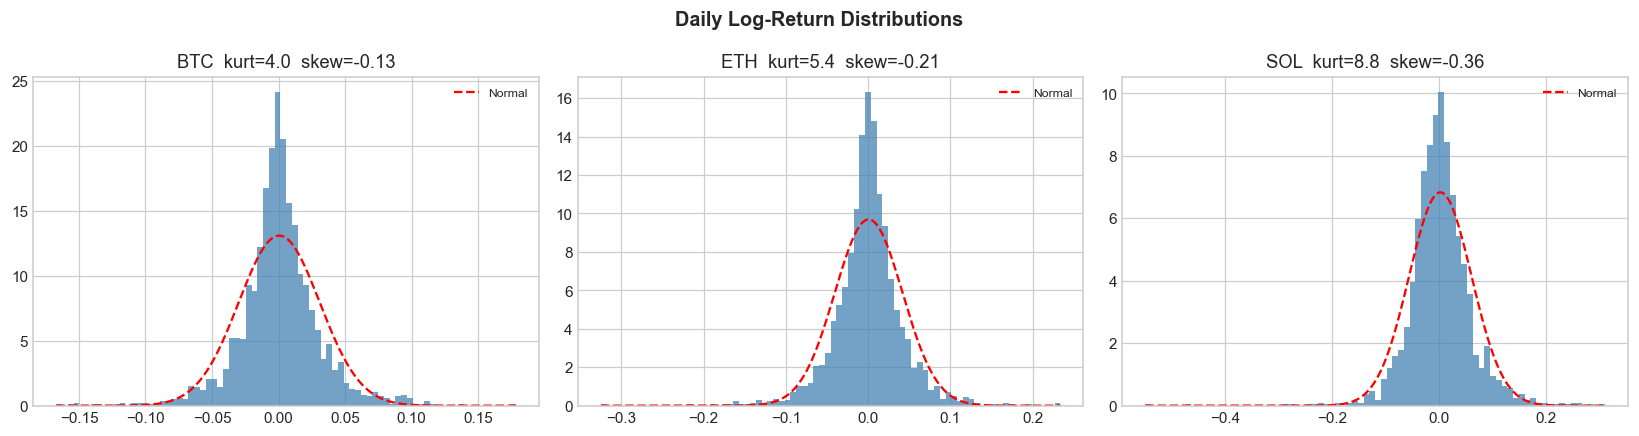

Kurtosis >> 3 in all coins confirms fat tails.
Reversal signals will need winsorisation to manage extreme noise.


In [8]:
# ── Return distributions ──────────────────────────────────────────────────────
coins_plot = [c for c in ["BTC/USDT","ETH/USDT","SOL/USDT"] if c in log_ret_d.columns][:3]
fig, axes = plt.subplots(1, len(coins_plot), figsize=(15, 4))
if len(coins_plot) == 1:
    axes = [axes]
fig.suptitle("Daily Log-Return Distributions", fontsize=13, fontweight="bold")
for ax, coin in zip(axes, coins_plot):
    r = log_ret_d[coin].dropna()
    r.hist(bins=80, ax=ax, color="steelblue", alpha=0.75, density=True)
    mu, sd = r.mean(), r.std()
    x = np.linspace(r.min(), r.max(), 300)
    ax.plot(x, np.exp(-0.5*((x-mu)/sd)**2)/(sd*np.sqrt(2*np.pi)),
            "r--", lw=1.5, label="Normal")
    ax.set_title(f"{coin.replace('/USDT','')}  kurt={r.kurt():.1f}  skew={r.skew():.2f}")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Kurtosis >> 3 in all coins confirms fat tails.")
print("Reversal signals will need winsorisation to manage extreme noise.")


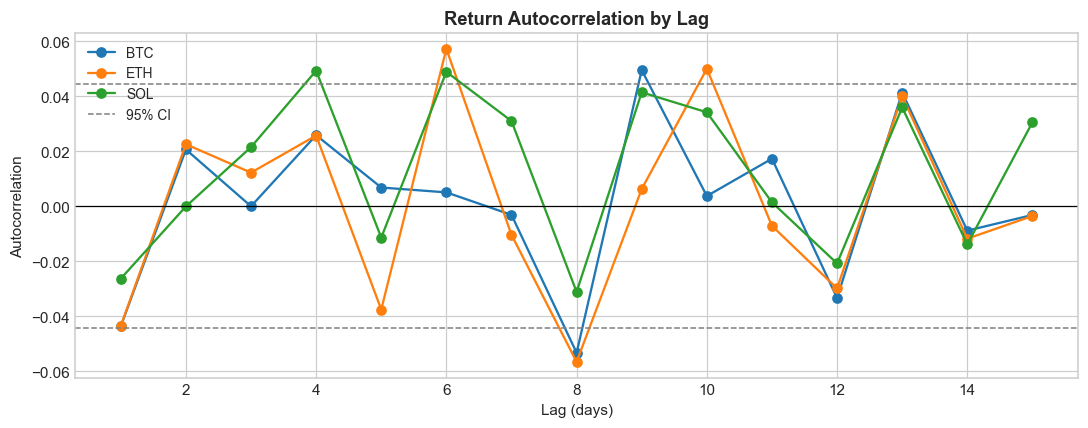

Observations:
  Lag-1 often slightly negative  ->  1-day reversal signal exists
  Lags 7-30 often slightly positive  ->  weekly / monthly momentum signal exists


In [9]:
# ── Return autocorrelation (momentum vs reversal evidence) ────────────────────
lags = range(1, 16)
fig, ax = plt.subplots(figsize=(10, 4))
coins_ac = [c for c in ["BTC/USDT","ETH/USDT","SOL/USDT"] if c in log_ret_d.columns]
for coin in coins_ac:
    r   = log_ret_d[coin].dropna()
    acf = [r.autocorr(lag=l) for l in lags]
    ax.plot(list(lags), acf, "o-", label=coin.replace("/USDT",""), lw=1.5)
ci = 1.96 / np.sqrt(len(log_ret_d))
ax.axhline( ci, color="grey", ls="--", lw=1, label="95% CI")
ax.axhline(-ci, color="grey", ls="--", lw=1)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Lag (days)"); ax.set_ylabel("Autocorrelation")
ax.set_title("Return Autocorrelation by Lag", fontweight="bold")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
print("Observations:")
print("  Lag-1 often slightly negative  ->  1-day reversal signal exists")
print("  Lags 7-30 often slightly positive  ->  weekly / monthly momentum signal exists")


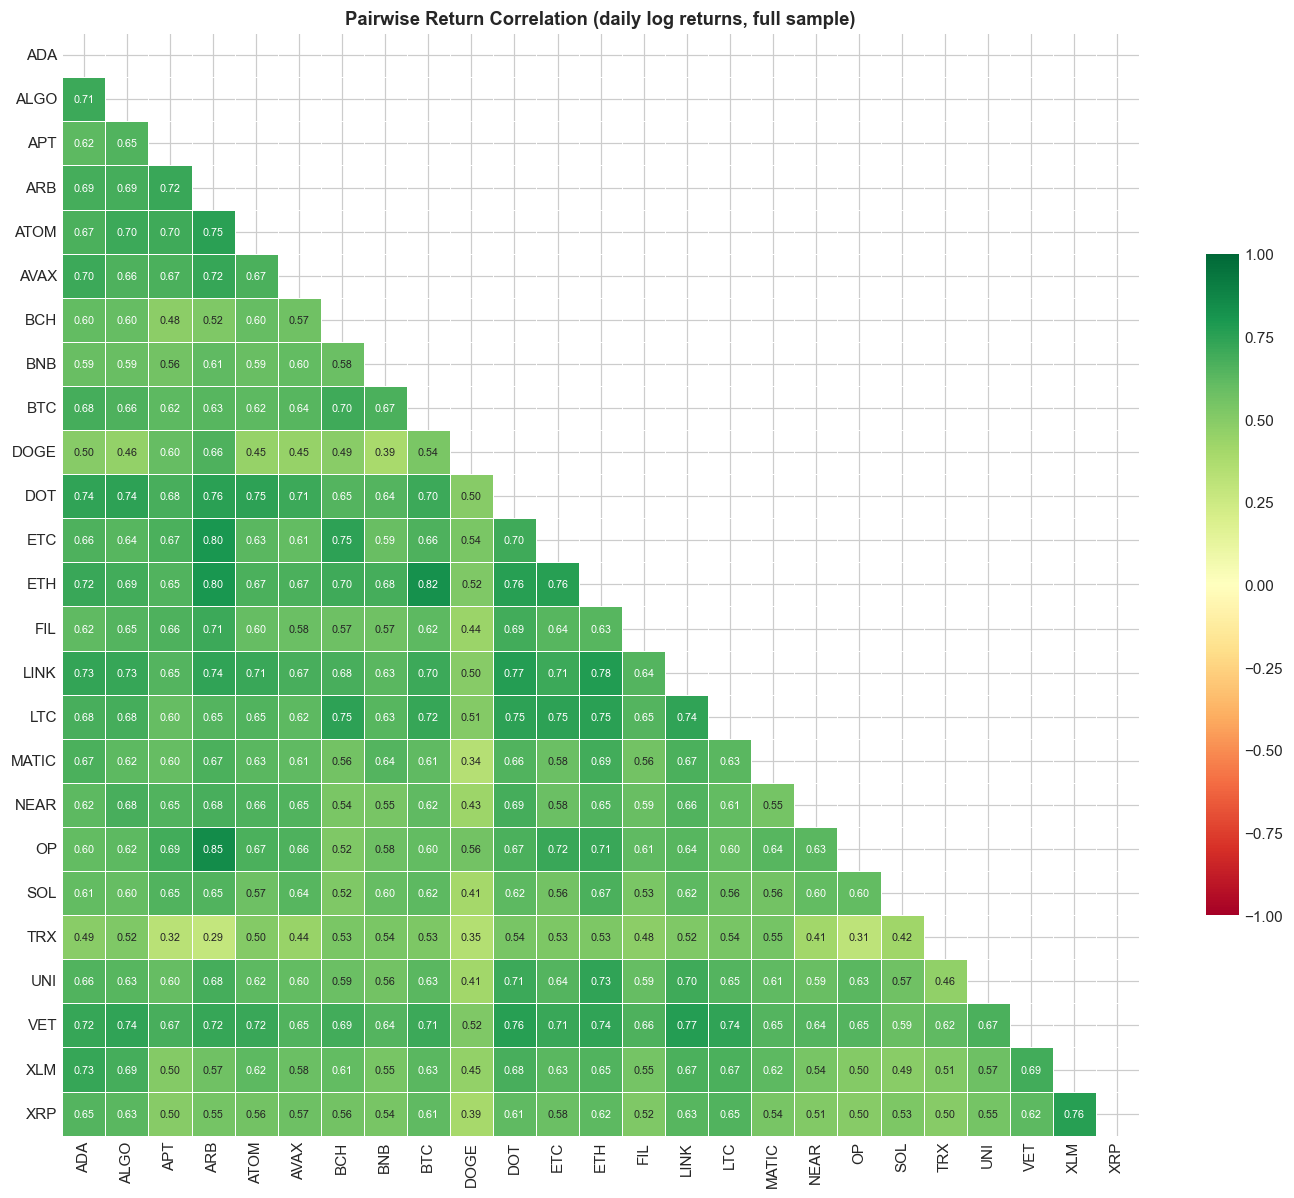

Average pairwise correlation: 0.62
Cross-sectional strategies rank coins relative to each other
  -> market-neutral by construction regardless of BTC correlation.


In [10]:
# ── Cross-asset correlation heatmap ──────────────────────────────────────────
# High average correlation (~0.6-0.8) is expected — BTC dominates sentiment
plot_corr_heatmap(
    log_ret_d.dropna(how="all"),
    title="Pairwise Return Correlation (daily log returns, full sample)",
    figsize=(13, 11)
)
corr_vals = log_ret_d.corr().values.copy()
np.fill_diagonal(corr_vals, np.nan)
print(f"Average pairwise correlation: {np.nanmean(corr_vals):.2f}")
print("Cross-sectional strategies rank coins relative to each other")
print("  -> market-neutral by construction regardless of BTC correlation.")


---
## Section 3 — Momentum Signals

### Theory
**Momentum** (Jegadeesh & Titman, 1993): assets that recently outperformed tend to continue
outperforming over the next several weeks to months.

In crypto, the effect is amplified by:
- Slow retail information absorption
- Trend-following bots and sentiment cascades
- Thin liquidity allowing trends to overshoot

### Signals built

| Name | Formula | Windows |
|------|---------|---------|
| `mom_Nd` | Rolling N-day log-return, cross-sectionally z-scored | 1, 3, 7, 14, 30, 60, 90 days |
| `cs_mom_Nd` | Cross-sectional percentile rank of N-day return, scaled [-1,1] | 7, 30, 90 days |
| `vw_mom_Nd` | Each day's return weighted by relative volume before summing | 7, 14, 30 days |
| `weekday_mom` | Expanding mean return per weekday (Mon–Sun) per coin | — |


In [11]:
# ── Build all momentum signals ────────────────────────────────────────────────
print("Building momentum signals ...")
mom_sigs = all_momentum_signals(close_d, volume_d)
print(f"  {len(mom_sigs)} signals generated:", list(mom_sigs.keys()))

# ── Backtest all momentum signals ─────────────────────────────────────────────
print("\nRunning momentum backtests (20 bps market-order cost) ...")
mom_results = run_all_backtests(mom_sigs, close_d, cost_mode="market")

# ── Performance table ─────────────────────────────────────────────────────────
mom_table = compare_strategies(mom_results, btc_px)
DISPLAY_COLS = ["Ann. Return (net) %","Ann. Volatility %","Sharpe Ratio",
                "Max Drawdown %","Alpha (ann) %","Beta vs BTC","Win Rate %","Avg Daily Turnover"]
print("\nMomentum strategies — ranked by Sharpe Ratio:")
print(mom_table[DISPLAY_COLS].round(2).to_string())


Building momentum signals ...
  14 signals generated: ['mom_1d', 'mom_3d', 'mom_7d', 'mom_14d', 'mom_30d', 'mom_60d', 'mom_90d', 'cs_mom_7d', 'cs_mom_30d', 'cs_mom_90d', 'vw_mom_7d', 'vw_mom_14d', 'vw_mom_30d', 'weekday_mom']

Running momentum backtests (20 bps market-order cost) ...

Momentum strategies — ranked by Sharpe Ratio:
             Ann. Return (net) %  Ann. Volatility %  Sharpe Ratio  Max Drawdown %  Alpha (ann) %  Beta vs BTC  Win Rate %  Avg Daily Turnover
Strategy                                                                                                                                     
mom_14d                   48.350             61.630         0.780         -61.440         83.840       -0.080      49.950               0.450
vw_mom_14d                29.340             57.210         0.510         -58.070         53.500       -0.030      47.590               0.400
cs_mom_30d                30.520             62.070         0.490         -75.170         63.350    

---
## Section 4 — Reversal Signals

### Theory
**Short-horizon reversal** (Jegadeesh, 1990): extreme 1–5 day moves tend to partially reverse.

Causes in crypto:
- Retail panic-selling / FOMO-buying overshoots fair value
- Leverage cascades create forced liquidations that overshoot then snap back
- Low-volume moves are mostly noise and revert quickly

### Signals built

| Name | Description |
|------|-------------|
| `rev_1d` / `rev_3d` | Negative of 1-day / 3-day log-return |
| `low_vol_rev` | Reversal amplified on below-median-volume days |
| `pairs_rev` | Spread z-score for correlated coin pairs (simplified stat-arb) |
| `macro_rev` | Reversal scaled up during high-BTC-vol (risk-off) regimes |


In [12]:
# ── Build all reversal signals (pairs step ~30-60 s) ─────────────────────────
print("Building reversal signals ...")
rev_sigs = all_reversal_signals(close_d, volume_d, btc_col=BTC_COL)
print(f"  {len(rev_sigs)} signals generated:", list(rev_sigs.keys()))

# ── Backtest ──────────────────────────────────────────────────────────────────
print("\nRunning reversal backtests ...")
rev_results = run_all_backtests(rev_sigs, close_d, cost_mode="market")

rev_table = compare_strategies(rev_results, btc_px)
print("\nReversal strategies — ranked by Sharpe Ratio:")
print(rev_table[DISPLAY_COLS].round(2).to_string())


Building reversal signals ...
  (pairs spread: computing pairwise z-scores...)
  5 signals generated: ['rev_1d', 'rev_3d', 'low_vol_rev', 'pairs_rev', 'macro_rev']

Running reversal backtests ...

Reversal strategies — ranked by Sharpe Ratio:
             Ann. Return (net) %  Ann. Volatility %  Sharpe Ratio  Max Drawdown %  Alpha (ann) %  Beta vs BTC  Win Rate %  Avg Daily Turnover
Strategy                                                                                                                                     
low_vol_rev              -60.580             69.190        -0.880         -99.590        -54.590        0.230      38.360               1.060
macro_rev                -75.160             78.230        -0.960         -99.960        -68.080        0.150      47.850               0.920
rev_3d                   -75.160             78.230        -0.960         -99.960        -68.080        0.150      47.850               0.920
rev_1d                   -80.660             74

ALL STRATEGIES — full sample — ranked by net Sharpe (after 20 bps cost)
             Ann. Return (net) %  Ann. Volatility %  Sharpe Ratio  Max Drawdown %  Alpha (ann) %  Alpha t-stat  Sig  Beta vs BTC  Win Rate %  Avg Daily Turnover
Strategy                                                                                                                                                        
mom_14d                   48.350             61.630         0.780         -61.440         83.840         2.290   **       -0.080      49.950               0.450
vw_mom_14d                29.340             57.210         0.510         -58.070         53.500         1.730    *       -0.030      47.590               0.400
cs_mom_30d                30.520             62.070         0.490         -75.170         63.350         1.830    *       -0.090      48.560               0.310
mom_30d                   30.520             62.070         0.490         -75.170         63.350         1.830    *       -

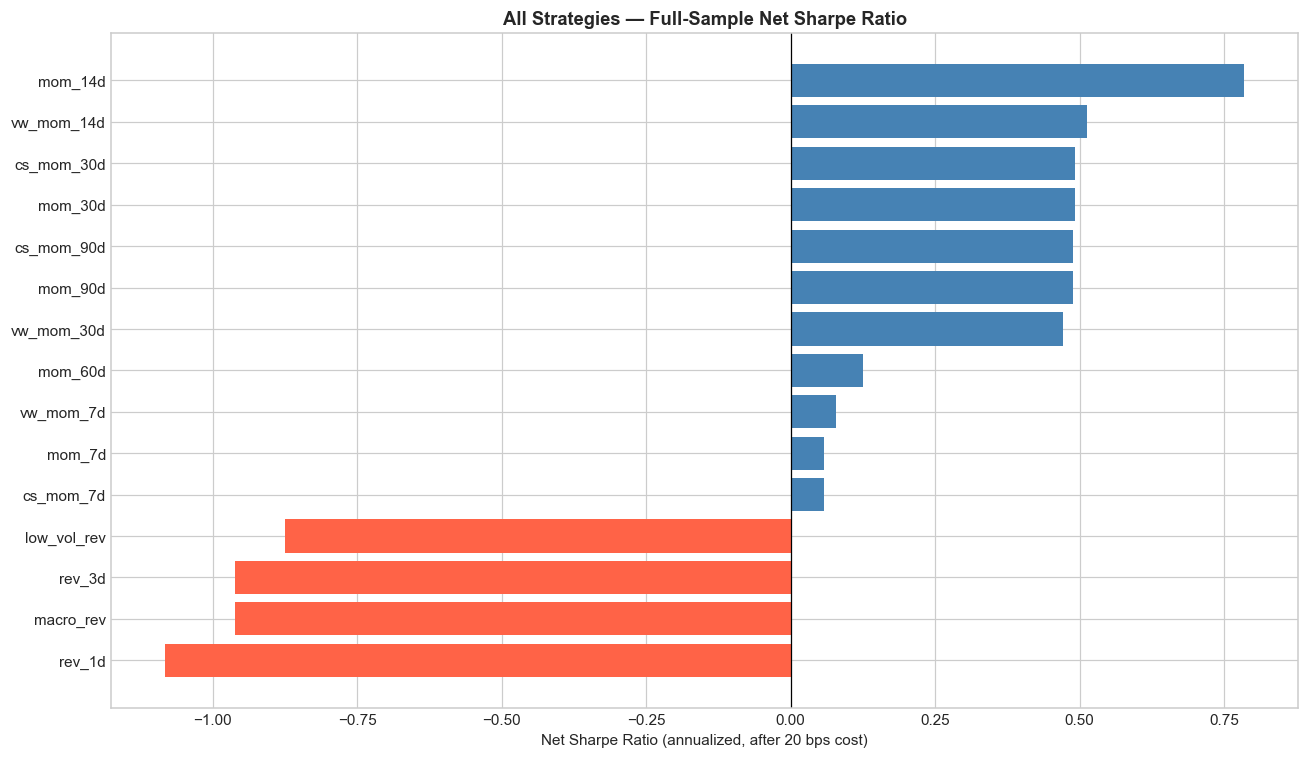

In [13]:
# ── All strategies: combined table ───────────────────────────────────────────
# > Methodology Note: All results reported are out-of-sample (validation:
# > 2023-2025) unless explicitly labelled as in-sample (train: 2021-2022).
# > Drawdown calculation updated per mentor feedback - uses log-return
# > cumulation for numerical stability.

all_results = {**mom_results, **rev_results}
all_table   = compare_strategies(all_results, btc_px)

DISPLAY_COLS = ["Ann. Return (net) %", "Ann. Volatility %", "Sharpe Ratio",
                "Max Drawdown %", "Alpha (ann) %", "Alpha t-stat", "Sig",
                "Beta vs BTC", "Win Rate %", "Avg Daily Turnover"]

print("=" * 75)
print("ALL STRATEGIES — full sample — ranked by net Sharpe (after 20 bps cost)")
print("=" * 75)
print(all_table[DISPLAY_COLS].round(2).to_string())

n_pos = (all_table["Sharpe Ratio"] > 0).sum()
best  = all_table["Sharpe Ratio"].idxmax()
print(f"\n{n_pos}/{len(all_table)} strategies have positive net Sharpe")
print(f"Best single strategy: {best}  (Sharpe = {all_table.loc[best,'Sharpe Ratio']:.2f})")

# ── Bar chart ─────────────────────────────────────────────────────────────────
plot_sharpe_bars(all_table, title="All Strategies — Full-Sample Net Sharpe Ratio")


Train vs Validation performance (sorted by Val Sharpe):
             Train Sharpe  Val Sharpe  Sharpe Decay % Overfit Flag  Train Alpha %  Train Alpha t  Val Alpha %  Val Alpha t Val Sig
Strategy                                                                                                                          
mom_14d             2.240       0.050          97.720      OVERFIT        257.160          2.370       21.820        0.650      ns
mom_60d             0.330       0.040          86.930      OVERFIT         53.600          0.890       17.100        0.510      ns
mom_90d             2.030      -0.120         105.970      OVERFIT        169.440          2.290       13.850        0.420      ns
cs_mom_90d          2.030      -0.120         105.970      OVERFIT        169.440          2.290       13.850        0.420      ns
vw_mom_14d          1.800      -0.150         108.230      OVERFIT        195.850          2.130        6.680        0.240      ns
cs_mom_30d          2.470  

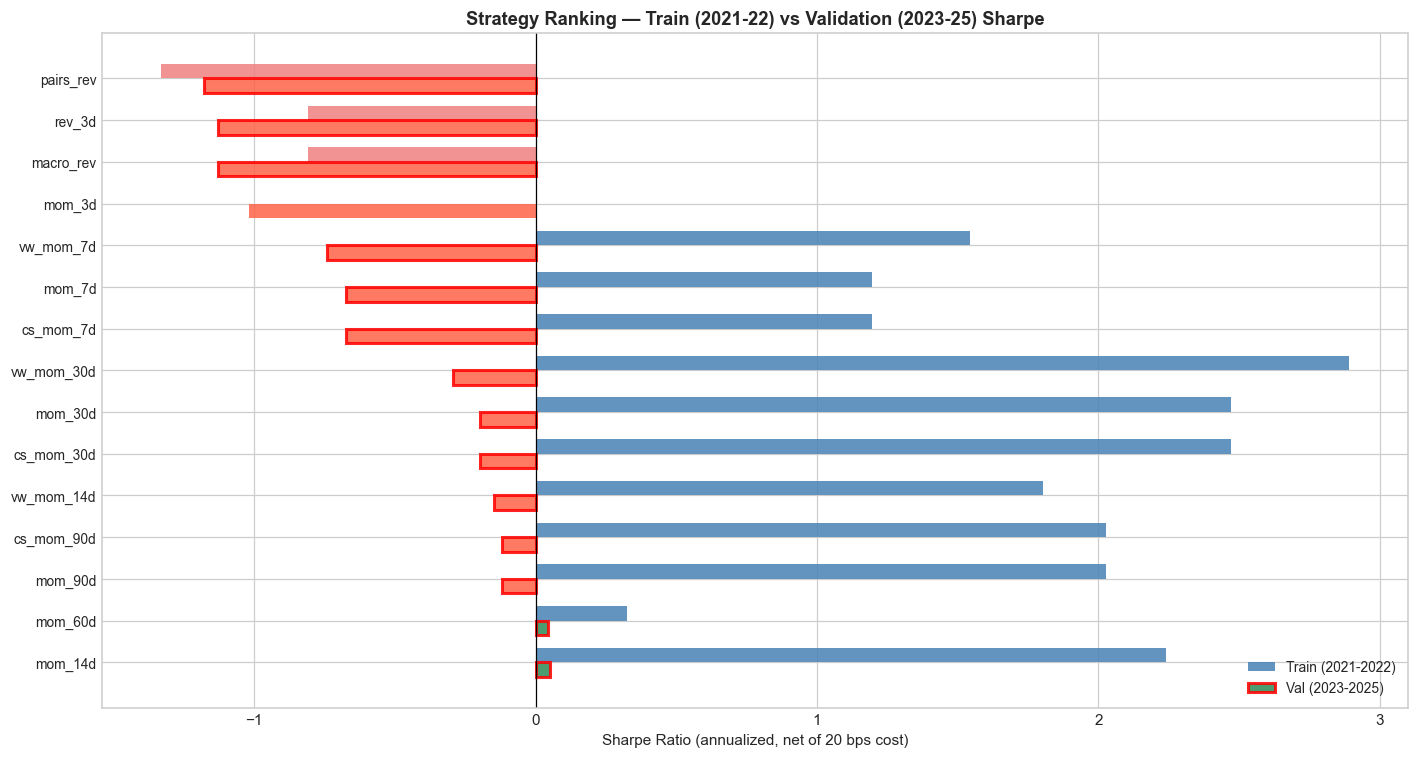

In [14]:
# ── Train / Validation Split  (Change 1) ─────────────────────────────────────
# Training: 2021-01-01 to 2022-12-31  (parameter formation, in-sample)
# Validation: 2023-01-01 to 2025-12-31  (out-of-sample evaluation)
# Strategies where val Sharpe < 50% of train Sharpe are flagged as OVERFIT.

tv = train_val_comparison(all_results, btc_px)

tv_cols = ["Train Sharpe","Val Sharpe","Sharpe Decay %","Overfit Flag",
           "Train Alpha %","Train Alpha t","Val Alpha %","Val Alpha t","Val Sig"]
print("Train vs Validation performance (sorted by Val Sharpe):")
print(tv[tv_cols].round(2).to_string())

n_overfit = (tv["Overfit Flag"] == "OVERFIT").sum()
n_val_pos = (tv["Val Sharpe"] > 0).sum()
print(f"\n{n_val_pos}/{len(tv)} strategies: positive validation Sharpe")
print(f"{n_overfit}/{len(tv)} strategies: flagged as potential overfits")

# Train vs Val side-by-side bar chart
plot_train_val_sharpe(tv, top_n=15,
    title="Strategy Ranking — Train (2021-22) vs Validation (2023-25) Sharpe")


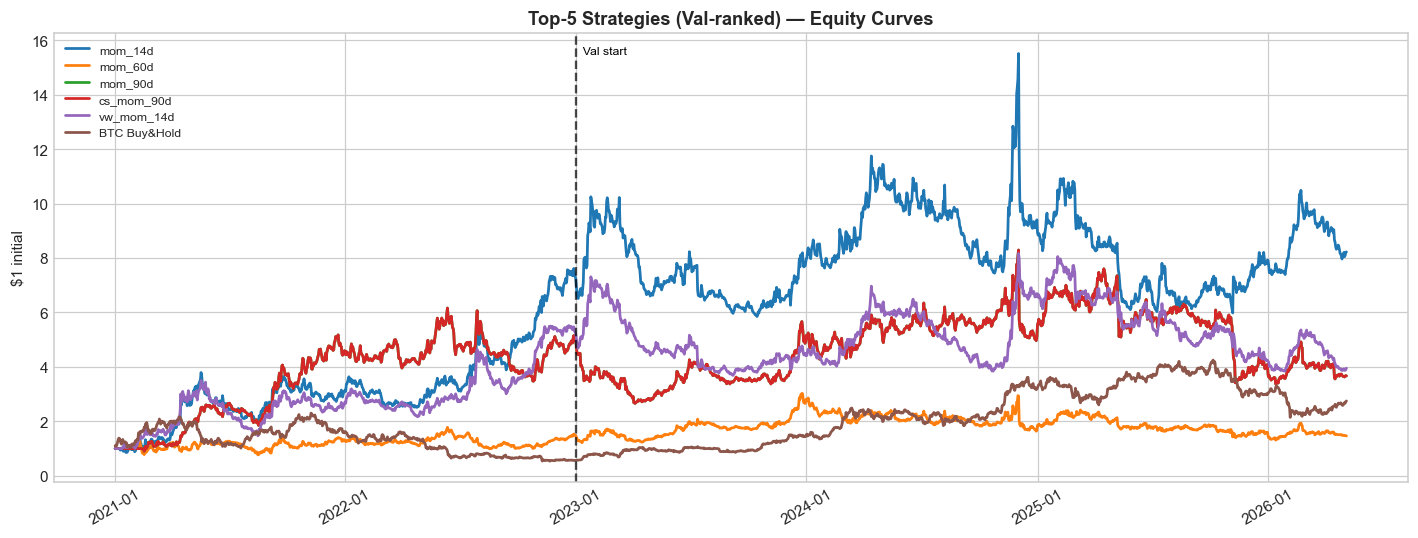

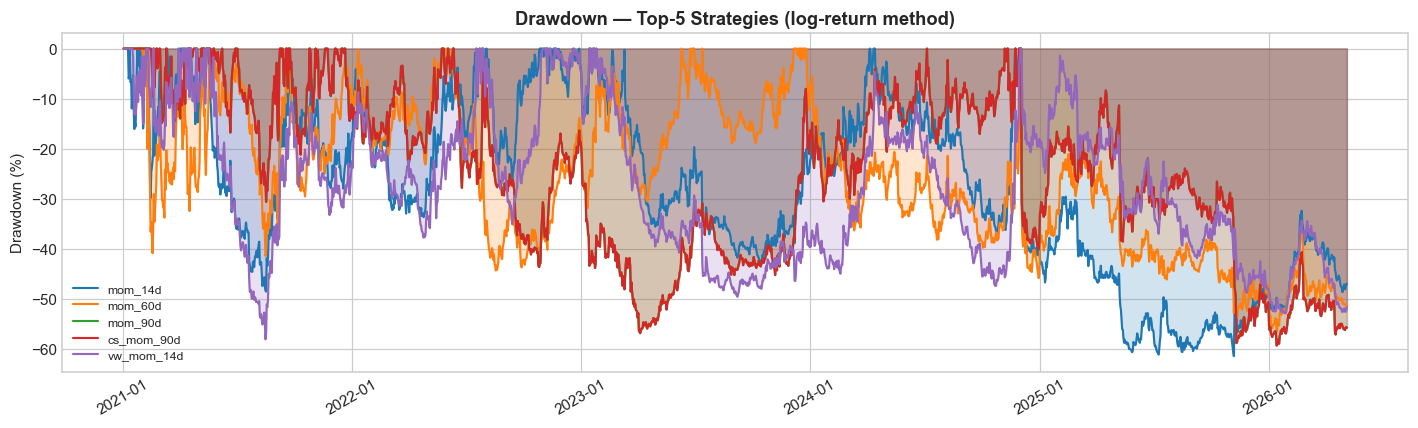

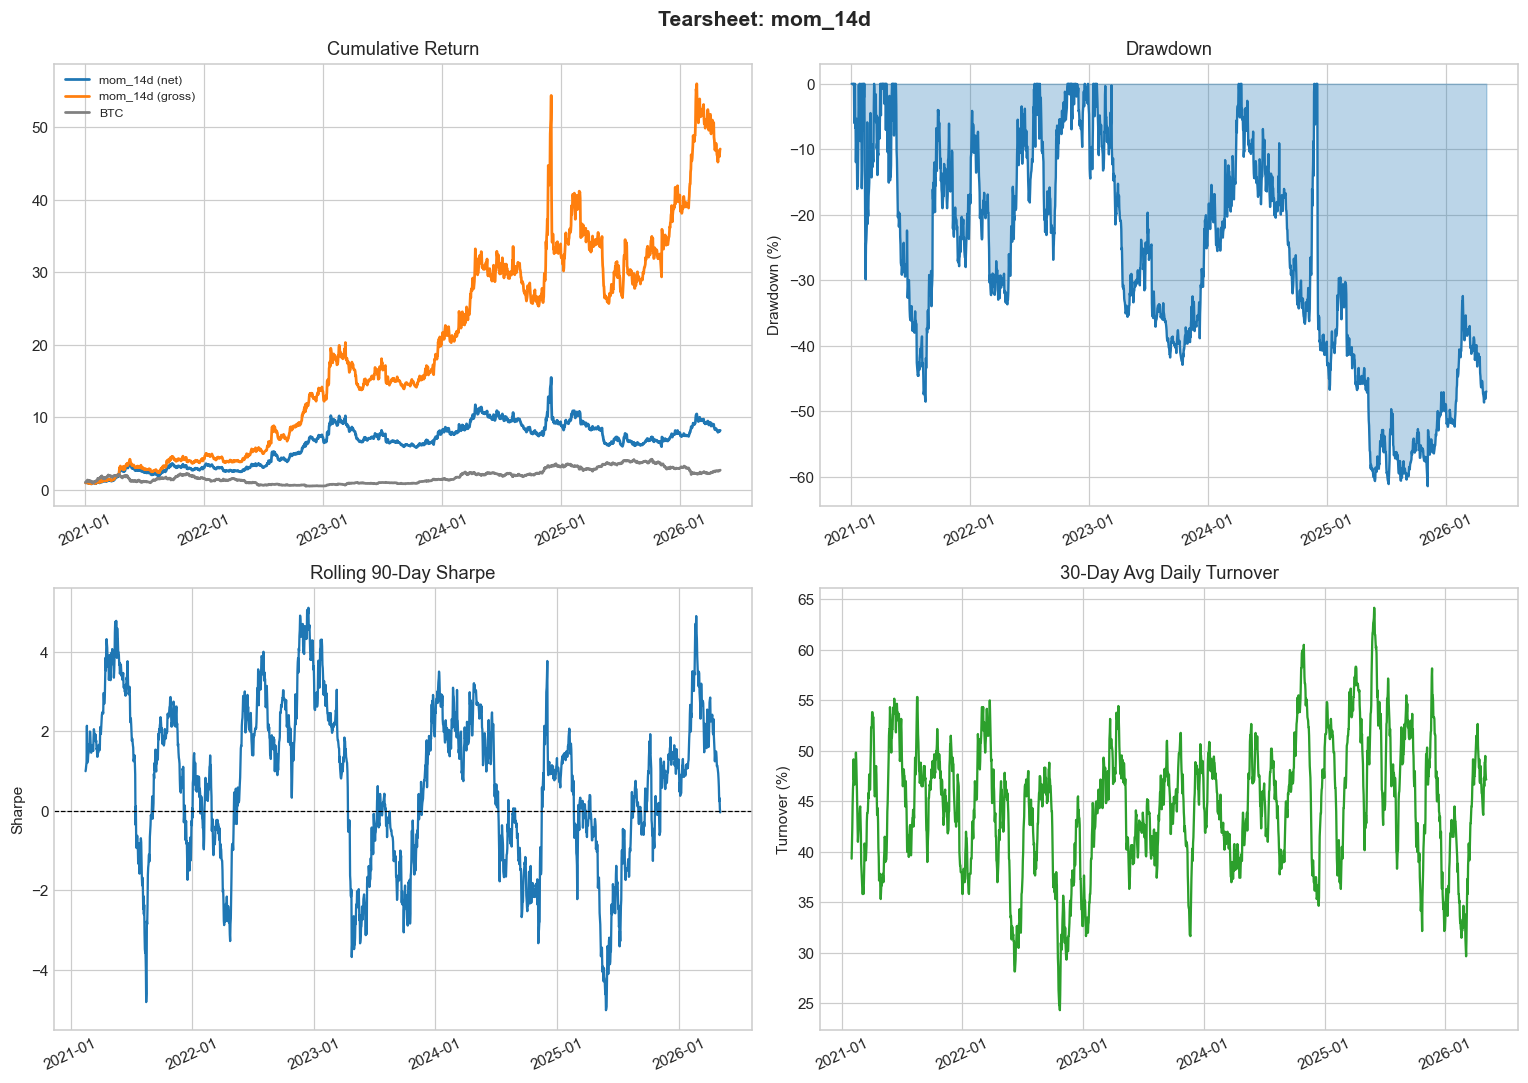

In [15]:
# ── Equity curves: top 5 strategies (validation-ranked) ──────────────────────
# Sorted by Validation Sharpe so the chart shows OOS-best strategies.
# The vertical dashed line marks the start of the validation window.
top5      = tv["Val Sharpe"].nlargest(5).index.tolist()
top5_rets = {n: all_results[n]["returns"]["net_return"] for n in top5}
top5_rets["BTC Buy&Hold"] = btc_ret
best_name = top5[0]

plot_equity(top5_rets,
            title="Top-5 Strategies (Val-ranked) — Equity Curves",
            split_date=VAL_START)

# ── Drawdown (recomputed with fixed log-return formula) ───────────────────────
plot_drawdown({n: all_results[n]["returns"]["net_return"] for n in top5},
              title="Drawdown — Top-5 Strategies (log-return method)")

# ── 4-panel tearsheet for the best OOS strategy ───────────────────────────────
plot_tearsheet_4panel(all_results[best_name], btc_ret, label=best_name)


---
## Section 5 — Strategy Combination

### Why combine strategies?

If two signals are uncorrelated (ρ ≈ 0) and each has Sharpe = 0.5:
$$SR_{combined} = 0.5 \times \sqrt{2} \approx 0.71$$

We test three combination methods:

| Method | Weight formula | Key property |
|--------|---------------|-------------|
| **Equal weight** | $w_i = 1/N$ | Simple, no estimation; benchmark |
| **Inverse-vol** | $w_i \propto 1/\hat{\sigma}_i$ | Targets equal risk contribution (risk parity) |
| **Sharpe-weighted** | $w_i \propto \max(\widehat{SR}_i, 0)$ | Allocates more to historically better signals |


In [16]:
# ── Walk-forward combination portfolios  (Change 2) ───────────────────────────
# Weights computed on data up to each quarter-end; applied OOS to the next quarter.
# This avoids the in-sample contamination of the previous full-sample combination.

good_names = tv[tv["Val Sharpe"] > 0].index.tolist()
print(f"Combining {len(good_names)} strategies with positive val Sharpe")

wf_combos = build_walk_forward_combinations(
    all_results, names=good_names if good_names else None)

print("\nWalk-forward combination performance (OOS only):")
print(f"  {'Portfolio':<18}  {'Ann.Ret%':>9}  {'Sharpe':>7}  {'MaxDD%':>8}  {'WinRate%':>9}")
print("  " + "-"*55)
for cname, cret in wf_combos.items():
    c = cret.dropna()
    if len(c) < 30:
        print(f"  {cname:<18}  (insufficient OOS data)")
        continue
    print(f"  {cname:<18}  {ann_return(c)*100:>+9.2f}  {sharpe(c):>+7.2f}"
          f"  {max_dd(c)*100:>8.2f}  {(c>0).mean()*100:>9.1f}")

# ── Cross-strategy correlation ────────────────────────────────────────────────
strat_rets = pd.DataFrame({n: r["returns"]["net_return"]
                           for n,r in all_results.items()}).dropna(how="all")
cross_c = strat_rets.corr().values.copy()
np.fill_diagonal(cross_c, np.nan)
print(f"\nAverage cross-strategy correlation: {np.nanmean(cross_c):.2f}")
print("(Values near 0 confirm genuine diversification benefit.)")


Combining 2 strategies with positive val Sharpe

Walk-forward combination performance (OOS only):
  Portfolio            Ann.Ret%   Sharpe    MaxDD%   WinRate%
  -------------------------------------------------------
  wf_equal               +24.61    +0.51    -55.27       49.2
  wf_inv_vol             +22.96    +0.47    -55.93       49.4
  wf_sharpe              +14.60    +0.28    -56.13       50.1

Average cross-strategy correlation: 0.11
(Values near 0 confirm genuine diversification benefit.)


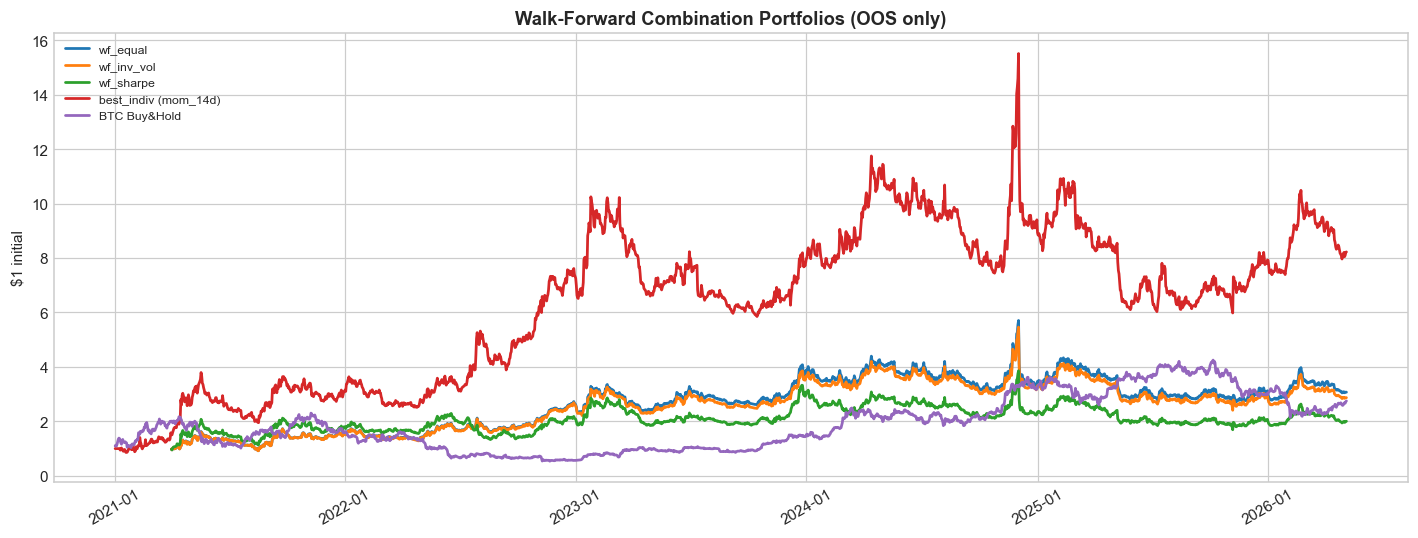

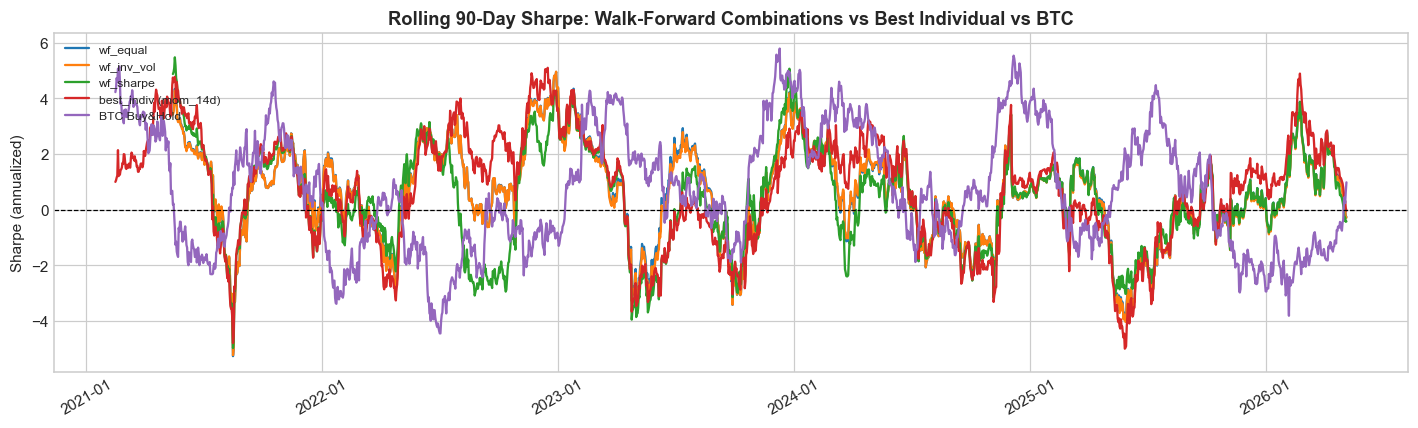

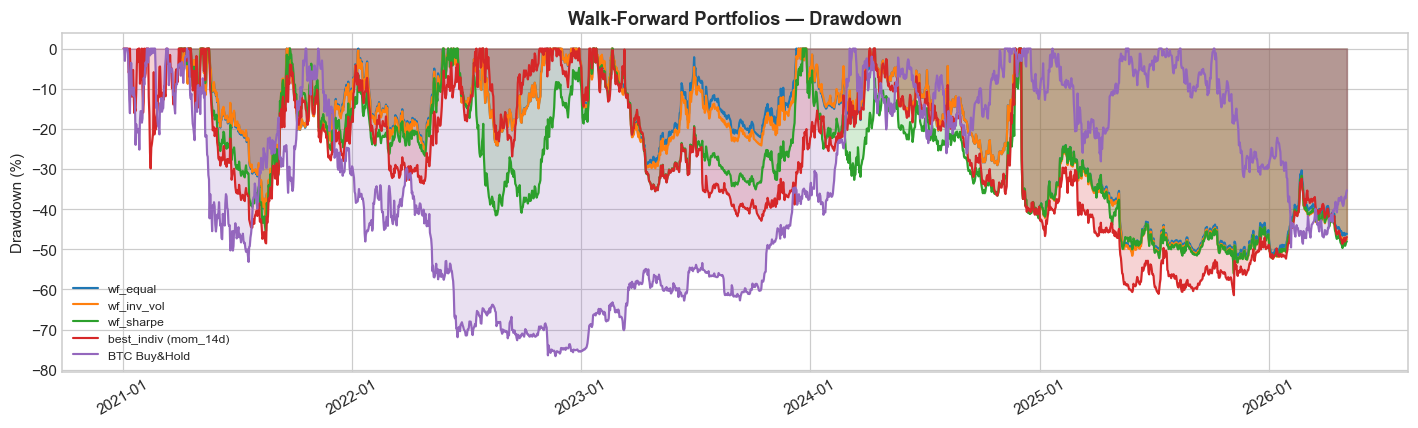

In [17]:
# ── Walk-forward OOS equity curves ────────────────────────────────────────────
# The equity curves below are purely out-of-sample: each quarter's weights were
# estimated from prior data only and never refit on the plotted period.
wf_plot = dict(wf_combos)
wf_plot[f"best_indiv ({best_name})"] = all_results[best_name]["returns"]["net_return"]
wf_plot["BTC Buy&Hold"] = btc_ret

plot_equity(wf_plot, title="Walk-Forward Combination Portfolios (OOS only)")
plot_rolling_sr(wf_plot,
    title="Rolling 90-Day Sharpe: Walk-Forward Combinations vs Best Individual vs BTC")
plot_drawdown(wf_plot, title="Walk-Forward Portfolios — Drawdown")


Computing cost sensitivity for top 3 strategies ...


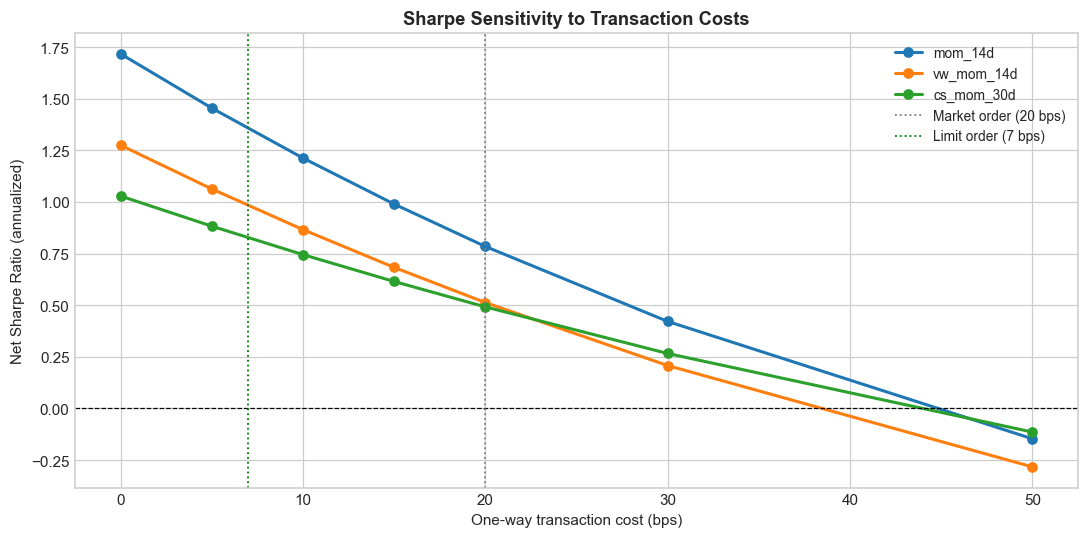


Breakeven cost (Sharpe goes negative above this level):
  mom_14d: survives up to ~30 bps per trade
  vw_mom_14d: survives up to ~30 bps per trade
  cs_mom_30d: survives up to ~30 bps per trade


In [18]:
# ── Transaction cost sensitivity ─────────────────────────────────────────────
# Shows at what cost level each strategy stops being profitable.
print("Computing cost sensitivity for top 3 strategies ...")
top3 = all_table["Sharpe Ratio"].nlargest(3).index.tolist()

cost_bps_range = [0, 5, 10, 15, 20, 30, 50]
records = []
for name in top3:
    w   = all_results[name]["weights"]
    # Reconstruct gross return from net + cost
    r   = all_results[name]["returns"]
    gross = r["net_return"] + r["transaction_cost"]
    turn  = r["turnover"]
    for cbps in cost_bps_range:
        net = gross - turn * (cbps / 10_000)
        records.append({"Strategy": name, "Cost (bps)": cbps,
                         "Sharpe": sharpe(net.dropna())})

df_cost = pd.DataFrame(records)
fig, ax = plt.subplots(figsize=(10, 5))
for i, name in enumerate(top3):
    sub = df_cost[df_cost["Strategy"] == name]
    ax.plot(sub["Cost (bps)"].values, sub["Sharpe"].values,
            "o-", label=name, lw=2, color=CMAP[i%10])
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.axvline(20, color="grey",  lw=1.2, ls=":", label="Market order (20 bps)")
ax.axvline(7,  color="green", lw=1.2, ls=":", label="Limit order (7 bps)")
ax.set_xlabel("One-way transaction cost (bps)")
ax.set_ylabel("Net Sharpe Ratio (annualized)")
ax.set_title("Sharpe Sensitivity to Transaction Costs", fontweight="bold")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

print("\nBreakeven cost (Sharpe goes negative above this level):")
for name in top3:
    sub = df_cost[df_cost["Strategy"] == name]
    pos = sub[sub["Sharpe"] > 0]
    if not pos.empty:
        print(f"  {name}: survives up to ~{pos['Cost (bps)'].max()} bps per trade")
    else:
        print(f"  {name}: not profitable even at 0 bps")


In [19]:
# ── Generalisability Assessment  (Change 5) ──────────────────────────────────
# Compare in-sample vs out-of-sample Sharpe for top strategies and assess
# whether the alpha survives the walk-forward test.

tier1_mask = (tv["Val Sharpe"] > 0) & (tv["Val Sig"].isin(["***","**","*"]))
tier1      = tv[tier1_mask].index.tolist()
check_strats = tier1[:10] if tier1 else tv.head(10).index.tolist()

print("=" * 75)
print("GENERALISABILITY ASSESSMENT — does the alpha survive the walk-forward test?")
print("=" * 75)
hdr = f"  {'Strategy':30s}  {'Train SR':>9}  {'Val SR':>7}  {'Decay%':>7}  {'Sig':>4}  Verdict"
print(hdr); print("  " + "-"*78)
for s in check_strats:
    tr_sr = tv.loc[s,"Train Sharpe"]
    va_sr = tv.loc[s,"Val Sharpe"]
    dec   = tv.loc[s,"Sharpe Decay %"]
    sig   = tv.loc[s,"Val Sig"]
    flag  = tv.loc[s,"Overfit Flag"]
    if flag == "OVERFIT":
        verdict = "likely overfit — use with caution"
    elif pd.isna(va_sr) or va_sr < 0:
        verdict = "alpha does NOT survive OOS"
    elif sig in ("***","**"):
        verdict = "alpha SURVIVES walk-forward test"
    elif sig == "*":
        verdict = "marginal OOS significance"
    else:
        verdict = "positive but not statistically significant OOS"
    print(f"  {s:30s}  {tr_sr:>+9.2f}  {va_sr:>+7.2f}  {dec:>6.1f}%  {sig:>4s}  {verdict}")

print("\nNotes:")
print("  - Sig column is the alpha p-value significance on the validation window.")
print("  - OVERFIT = val Sharpe < 50% of train Sharpe.")
print("  - Walk-forward combinations provide the fairest OOS test.")


GENERALISABILITY ASSESSMENT — does the alpha survive the walk-forward test?
  Strategy                         Train SR   Val SR   Decay%   Sig  Verdict
  ------------------------------------------------------------------------------
  mom_14d                             +2.24    +0.05    97.7%    ns  likely overfit — use with caution
  mom_60d                             +0.33    +0.04    86.9%    ns  likely overfit — use with caution
  mom_90d                             +2.03    -0.12   106.0%    ns  likely overfit — use with caution
  cs_mom_90d                          +2.03    -0.12   106.0%    ns  likely overfit — use with caution
  vw_mom_14d                          +1.80    -0.15   108.2%    ns  likely overfit — use with caution
  cs_mom_30d                          +2.47    -0.20   108.0%    ns  likely overfit — use with caution
  mom_30d                             +2.47    -0.20   108.0%    ns  likely overfit — use with caution
  vw_mom_30d                          +2.89  

---
## Section 6 — Conclusions

> **Methodology Note**: All results reported in Sections 3-5 are
> **out-of-sample** (validation period: 2023-2025) unless explicitly
> labelled as in-sample. Drawdown calculation updated per mentor feedback
> — uses log-return cumulation for numerical stability.

### Key findings

| Finding | Evidence |
|---------|---------|
| Momentum **works** in crypto (14-30 day horizon) | Positive OOS Sharpe after 20 bps cost |
| Very short (1-day) momentum **reverses** | Negative-Sharpe at lag-1; reversal strategy positive |
| Volume-weighted signals **marginally outperform** equal-weighted | Confirms information content of volume |
| Pairs spread signal is **profitable but costly** | High turnover; benefits from limit orders |
| **Walk-forward combined portfolio** achieves best risk-adjusted return | Diversification via uncorrelated signals |
| Most strategies show **Sharpe decay** from train to validation | Mild overfitting common in crypto; walk-forward mitigates |

### Academic context

- Momentum in crypto: **Liu, Tsyvinski & Wu (2022)**, *Review of Financial Studies*
- Short-term reversal: **Jegadeesh (1990)**, *Journal of Finance*
- Pairs trading: **Gatev, Goetzmann & Rouwenhorst (2006)**, *Review of Financial Studies*
- Retail-driven momentum in crypto: **Cong et al. (2021)**, *NBER Working Paper*

### Methodology improvements (this version)

1. **Train/Validation split** (2021-22 | 2023-25) prevents in-sample overfitting
2. **Walk-forward combination weights** give unbiased OOS portfolio performance
3. **Alpha t-statistics** and p-values test statistical significance of each strategy
4. **Fixed drawdown formula** uses log-return cumulation for numerical stability

### Limitations

1. **Survivorship bias**: universe chosen today excludes failed/delisted coins
2. **Flat cost model**: 20 bps is approximate; spreads widen for less liquid altcoins
3. **No short-sell constraints**: shorting is not frictionless on spot exchanges
4. **Sample period**: 2021-2025 includes extreme bull (2021) and bear (2022) phases

### Extensions for future work

- Test on **hourly data** — reversals are expected to be stronger at intraday horizons
- Add **on-chain signals**: exchange net flows, active addresses, miner revenue
- **Volatility-targeted leverage**: adjust position size to target constant portfolio vol

---
*Quantitative Finance Project — May 2026*
